In [2]:
import pandas as pd
import numpy as np

# Step 1: Create raw DataFrame
data = {
    "employee_id": [101, 102, 103, 104, 105, 102, 106, 107, 108, 109],
    "name": [
        "Alice Johnson",
        "bob smith",
        "Charlie Brown",
        "Diana",
        "Eve Adams",
        "bob smith",
        "Frank ",
        " Grace Lee",
        "Hank",
        "Ivy Clarke",
    ],
    "department": [
        "HR",
        "IT",
        "Finance",
        "hr",
        "IT",
        "IT",
        "FINANCE",
        "HR",
        None,
        "Finance",
    ],
    "age": [29, 34, 45, 27, None, 34, 300, 38, 25, 31],
    "salary": [
        "$52,000",
        "$78,000",
        "$91,000",
        "$48,500",
        "$85,000",
        "$78,000",
        "$102,000",
        "$67,000",
        "$54,000",
        None,
    ],
    "join_date": [
        "2021-03-15",
        "2019-07-22",
        "2018-01-10",
        "2022-11-05",
        "2020-06-30",
        "2019-07-22",
        "2017-09-01",
        "2023-02-14",
        "2021-08-19",
        "2022-04-03",
    ],
    "rating": [4.2, 3.8, 4.5, None, 4.0, 3.8, 4.1, 3.5, None, 4.3],
}

df = pd.DataFrame(data)

# Step 2: Initial inspection
print("Shape:", df.shape)
print(df.info())
print(df.head())

Shape: (10, 7)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  10 non-null     int64  
 1   name         10 non-null     str    
 2   department   9 non-null      str    
 3   age          9 non-null      float64
 4   salary       9 non-null      str    
 5   join_date    10 non-null     str    
 6   rating       8 non-null      float64
dtypes: float64(2), int64(1), str(4)
memory usage: 692.0 bytes
None
   employee_id           name department   age   salary   join_date  rating
0          101  Alice Johnson         HR  29.0  $52,000  2021-03-15     4.2
1          102      bob smith         IT  34.0  $78,000  2019-07-22     3.8
2          103  Charlie Brown    Finance  45.0  $91,000  2018-01-10     4.5
3          104          Diana         hr  27.0  $48,500  2022-11-05     NaN
4          105      Eve Adams         IT   NaN  $85,000  2020-06-30  

In [3]:
# Standardize column names
df.columns = df.columns.str.lower().str.strip()

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates(subset=["employee_id", "name"])

Duplicate rows: 1


In [4]:
# Clean names
df["name"] = df["name"].str.strip().str.title()

# Standardize department
df["department"] = df["department"].str.strip().str.upper()

# Convert salary to numeric
df["salary"] = df["salary"].str.replace(r"[$,]", "", regex=True).astype(float)

# Convert join_date to datetime
df["join_date"] = pd.to_datetime(df["join_date"])

In [5]:
print("Missing values:\n", df.isnull().sum())

# Fill missing ages with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing salary with median
df["salary"] = df["salary"].fillna(df["salary"].median())

# Fill missing rating with mean
df["rating"] = df["rating"].fillna(df["rating"].mean())

# Fill missing department with 'UNKNOWN'
df["department"] = df["department"].fillna("UNKNOWN")

Missing values:
 employee_id    0
name           0
department     1
age            1
salary         1
join_date      0
rating         2
dtype: int64


In [6]:
# Replace unrealistic ages (>100) with NaN, then impute
df.loc[df["age"] > 100, "age"] = np.nan
df["age"] = df["age"].fillna(df["age"].median())

In [7]:
# Extract year of joining
df["join_year"] = df["join_date"].dt.year

# Salary in thousands
df["salary_k"] = df["salary"] / 1000

In [8]:
print(df.describe(include="all"))
print(df.sample(5))

        employee_id           name department        age         salary  \
count      9.000000              9          9   9.000000       9.000000   
unique          NaN              9          4        NaN            NaN   
top             NaN  Alice Johnson         HR        NaN            NaN   
freq            NaN              1          3        NaN            NaN   
mean     105.000000            NaN        NaN  32.583333   72222.222222   
min      101.000000            NaN        NaN  25.000000   48500.000000   
25%      103.000000            NaN        NaN  29.000000   54000.000000   
50%      105.000000            NaN        NaN  31.750000   72500.000000   
75%      107.000000            NaN        NaN  34.000000   85000.000000   
max      109.000000            NaN        NaN  45.000000  102000.000000   
std        2.738613            NaN        NaN   6.023392   18597.901614   

                  join_date    rating    join_year    salary_k  
count                     9  9.000

In [9]:
# Average salary by department
dept_salary = df.groupby("department")["salary"].mean()
print(dept_salary)

# Highest rated employee
highest_rating = df.loc[df["rating"].idxmax()]
print("Top performer:", highest_rating["name"], highest_rating["rating"])

department
FINANCE    88500.000000
HR         55833.333333
IT         81500.000000
UNKNOWN    54000.000000
Name: salary, dtype: float64
Top performer: Charlie Brown 4.5


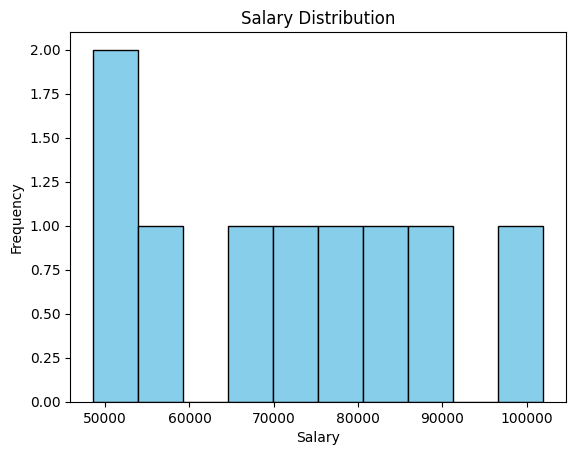

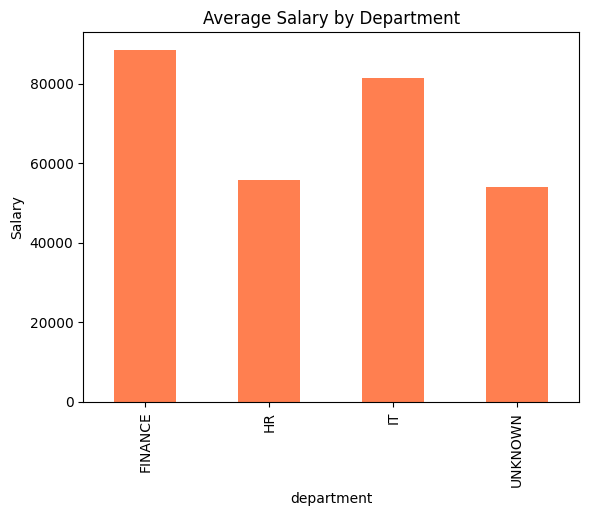

In [10]:
import matplotlib.pyplot as plt

# Salary distribution
df["salary"].plot(kind="hist", bins=10, color="skyblue", edgecolor="black")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

# Average salary by department
dept_salary.plot(kind="bar", color="coral")
plt.title("Average Salary by Department")
plt.ylabel("Salary")
plt.show()